# Multivariate Exploratory Data Analysis

This notebook performs multivariate exploratory data analysis on the Gurgaon properties dataset. Multivariate analysis examines relationships between multiple variables simultaneously to understand correlations, interactions, and patterns that may not be apparent in univariate analysis.

## Data Loading 

Load the cleaned dataset and configure display options for better data exploration.

In [173]:
# Import required libraries
from config import DATA_PROCESSED
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [174]:
# Configure pandas to display all columns
pd.set_option('display.max_columns', None)

In [175]:
# Load the cleaned dataset
df = pd.read_csv(DATA_PROCESSED / 'gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [176]:
# Display the first few rows
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,1,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,1,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,1,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,1,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,2,174


## Categorical vs Numerical Variables Analysis

Analyze relationships between categorical variables (like property_type) and numerical variables (like price, area, price_per_sqft) to understand how property characteristics influence pricing and other metrics.

### property_type vs price

<Axes: xlabel='property_type', ylabel='price'>

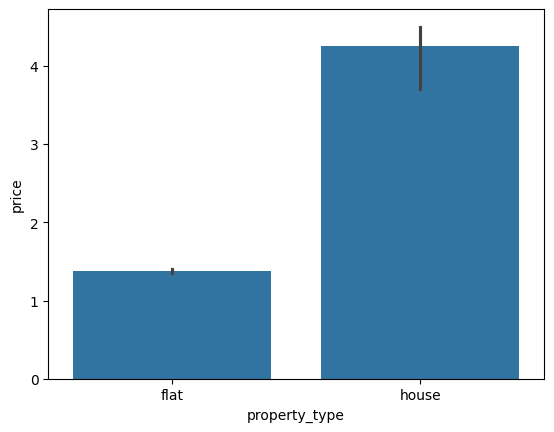

In [177]:
sns.barplot(x=df['property_type'], y=df['price'], estimator=np.median)

<Axes: xlabel='property_type', ylabel='price'>

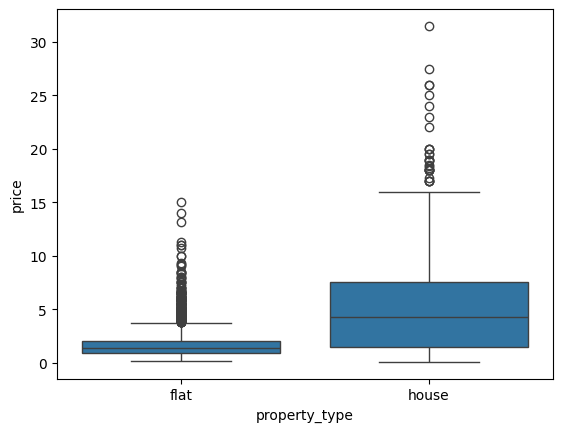

In [178]:
sns.boxplot(x=df['property_type'], y=df['price'])

#### Observation

- Houses are significantly more expensive than flats<br>
Flats: 1.4 crores<br>
Houses: 4.2 crores<br>
On average, houses cost nearly 3× more than flats.

- Price spread (IQR) is far larger for houses <br>
Flats: Narrow interquartile range (IQR) <br>
Most flats fall between 1–2.5 crores <br>
Houses: Wide IQR <br>
Prices commonly range from ~2–7 crores

### property_type vs area

<Axes: xlabel='property_type', ylabel='built_up_area'>

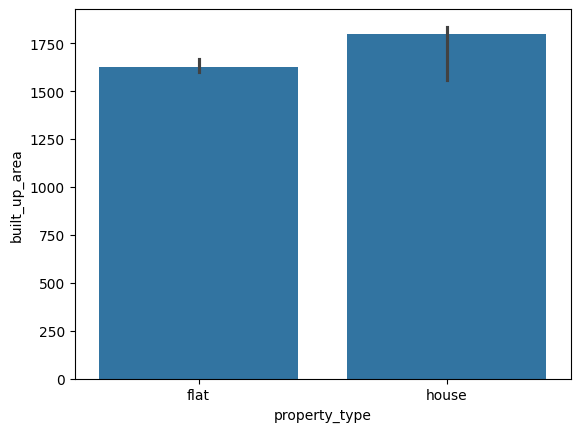

In [179]:
sns.barplot(x=df['property_type'], y=df['built_up_area'], estimator=np.median)

<Axes: xlabel='property_type', ylabel='built_up_area'>

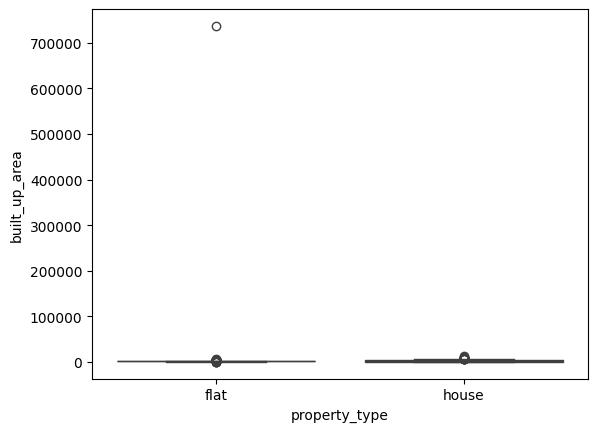

In [180]:
sns.boxplot(x=df['property_type'], y=df['built_up_area'])

In [181]:
# removing outlier
df = df[df['built_up_area'] != 737147]

<Axes: xlabel='property_type', ylabel='built_up_area'>

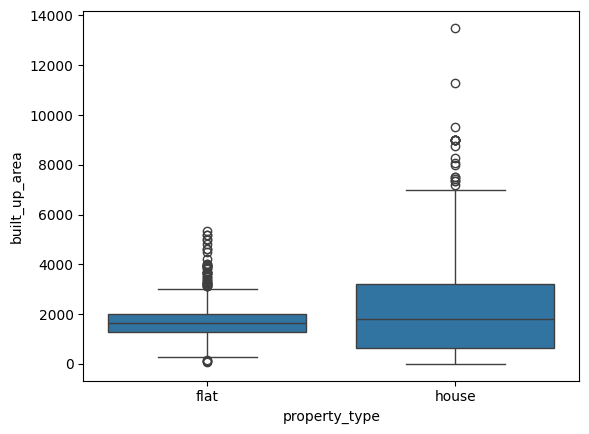

In [182]:
sns.boxplot(x=df['property_type'], y=df['built_up_area'])

#### Observations

- Houses have a **higher median built-up area** than flats.
- Flats show **less variation**, indicating more standardized sizes.
- Houses exhibit **greater dispersion and extreme outliers**, reflecting size heterogeneity.
- Both property types show **right-skewed distributions**.

### property_type vs price_per_sqft

<Axes: xlabel='property_type', ylabel='price_per_sqft'>

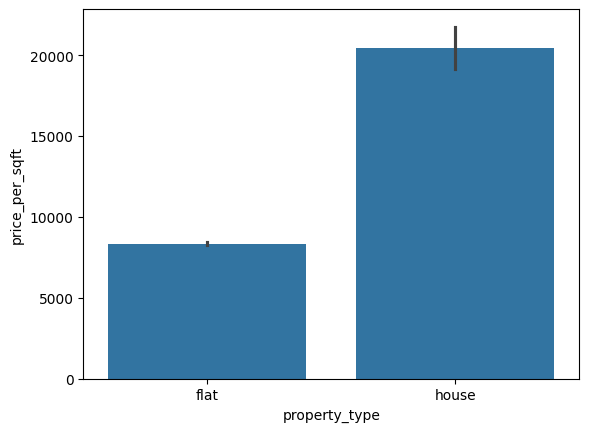

In [183]:
sns.barplot(x=df['property_type'], y=df['price_per_sqft'], estimator=np.median)

<Axes: xlabel='property_type', ylabel='price_per_sqft'>

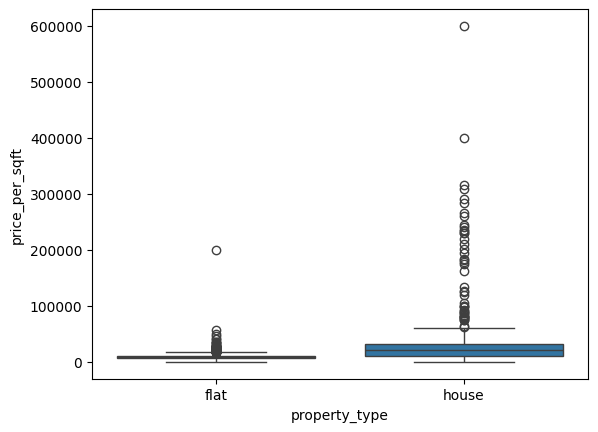

In [184]:
sns.boxplot(x=df['property_type'], y=df['price_per_sqft'])

In [185]:
# check outliers
df[df['price_per_sqft'] > 100000][['property_type','society','sector','price','price_per_sqft','area','areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,super_built_up_area,built_up_area,carpet_area
229,house,rk excelo,sector 12,0.60,120000.0,50.0,Plot area 50(4.65 sq.m.)Built Up area: 30 sq.f...,NaN,30.0,15.0
336,house,independent,sector 28,4.50,125000.0,360.0,Built Up area: 360 (33.45 sq.m.),NaN,360.0,NaN
342,house,unitech nirvana birch court,sector 50,7.10,283333.0,251.0,Plot area 240(22.3 sq.m.),NaN,240.0,NaN
545,house,independent,sector 24,10.00,229885.0,435.0,Carpet area: 435 (40.41 sq.m.),NaN,NaN,435.0
867,house,ardee city,sector 52,5.50,183333.0,300.0,Plot area 300(27.87 sq.m.),NaN,300.0,NaN
975,house,uppal southend,sector 49,6.75,290948.0,232.0,Plot area 232(21.55 sq.m.),NaN,232.0,NaN
1027,house,dlf the grove,sector 54,5.70,211111.0,270.0,Built Up area: 270 (25.08 sq.m.),NaN,270.0,NaN
1062,house,independent,sector 23,2.80,161849.0,173.0,Plot area 173(16.07 sq.m.)Built Up area: 160 s...,NaN,160.0,150.0
1259,house,vipul tatvam villa,sector 48,7.25,201388.0,360.0,Plot area 360(33.45 sq.m.),NaN,360.0,NaN
1385,house,unitech uniworld resorts,sector 33,9.50,173992.0,546.0,Plot area 546(50.73 sq.m.),NaN,546.0,NaN


#### Observations

- Houses have a **higher median price per sqft** than flats.
- The distribution for both property types is **right-skewed**, with extreme upper-end outliers.
- Several **very high price-per-sqft outliers ( > ₹1,00,000 )** are observed, mainly for houses.
- These extreme values are **data errors caused by incorrect area unit conversions**, leading to artificially inflated price-per-sqft values.

### property_type vs bedRoom

<Axes: xlabel='bedRoom', ylabel='property_type'>

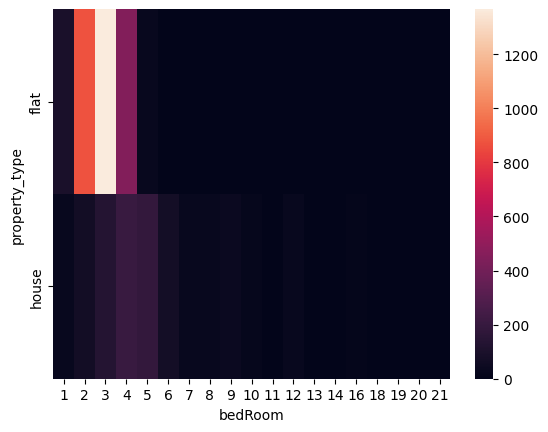

In [186]:
sns.heatmap(pd.crosstab(df['property_type'],df['bedRoom']))

In [187]:
# checking outliers
df[df['bedRoom'] >= 10]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
19,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,0,70
48,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,1,7
66,house,independent,sector 13,0.50,90909.0,55.0,Plot area 55(5.11 sq.m.),12,4,3,4.0,NaN,Old Property,NaN,55.0,NaN,0,0,0,0,0,1,15
78,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,1,68
119,house,independent,sector 55,7.49,27741.0,2700.0,Plot area 300(250.84 sq.m.),12,12,3+,4.0,South-East,Relatively New,NaN,2700.0,NaN,1,1,0,1,0,2,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3479,house,independent,sector 25,NaN,NaN,NaN,Plot area 250(209.03 sq.m.)Built Up area: 260 ...,12,12,3+,4.0,North-East,New Property,NaN,260.0,245.0,1,1,0,1,1,0,144
3519,house,huda plot sector 38,sector 38,4.30,245398.0,175.0,Plot area 163(15.14 sq.m.)Built Up area: 145 s...,13,13,3+,5.0,North-West,Relatively New,NaN,145.0,NaN,0,0,0,0,0,0,7
3618,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,0,49
3698,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,2700.0,NaN,0,1,0,1,0,2,49


#### Observations

- Flats are **concentrated in lower bedroom counts (1–3 BHK)**.
- Houses span a **wider range of bedrooms**, commonly 3–6 BHK.
- Very high bedroom counts (≥10) appear **almost exclusively for houses**.
- These extreme bedroom values represent **data errors.**

### property_type vs floorNum

<Axes: xlabel='property_type', ylabel='floorNum'>

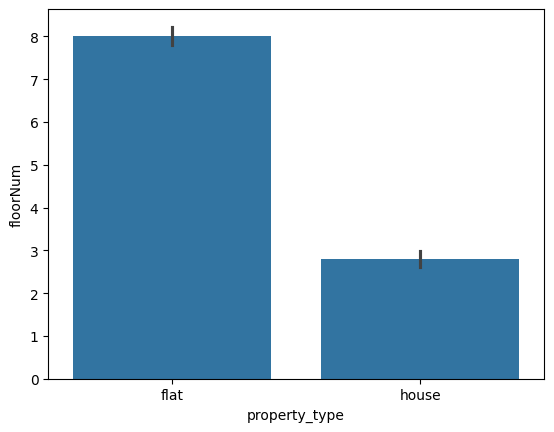

In [188]:
sns.barplot(x=df['property_type'],y=df['floorNum'])

<Axes: xlabel='property_type', ylabel='floorNum'>

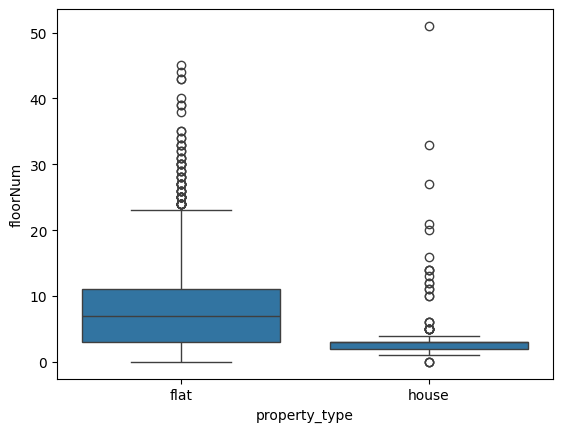

In [189]:
sns.boxplot(x=df['property_type'],y=df['floorNum'])

In [190]:
# checking for outliers
df[(df['property_type'] == 'house') & (df['floorNum'] > 10)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
35,house,greenopolis,sector 89,0.70,5397.0,1297.0,Built Up area: 1297 (120.5 sq.m.),2,2,2,14.0,North-East,Undefined,NaN,1297.0,NaN,0,0,0,0,0,1,0
106,house,suncity avenue 76,sector 76,0.75,10067.0,745.0,Plot area 745(69.21 sq.m.)Built Up area: 745 s...,2,2,2,11.0,North-East,New Property,NaN,745.0,NaN,0,0,0,0,0,1,40
267,house,ninex city,sector 76,1.75,6250.0,2800.0,Carpet area: 2800 (260.13 sq.m.),4,4,0,14.0,NaN,Undefined,NaN,NaN,2800.0,0,0,0,0,0,1,0
338,house,spaze privy,sector 72,3.09,6981.0,4426.0,Built Up area: 3653 (339.37 sq.m.)Carpet area:...,5,5,3+,14.0,East,Relatively New,NaN,3653.0,2922.0,0,1,0,0,0,2,33
420,house,spaze privy,sector 72,3.10,8486.0,3653.0,Plot area 3653(339.37 sq.m.),5,5,3+,21.0,NaN,Relatively New,NaN,3653.0,NaN,0,0,0,0,0,1,0
1297,house,indiabulls centrum park,sector 103,3.25,8125.0,4000.0,Plot area 4000(371.61 sq.m.),4,3,3+,20.0,NaN,Under Construction,NaN,4000.0,NaN,0,0,0,0,0,1,51
2147,house,ireo victory valley,sector 67,8.00,22222.0,3600.0,Plot area 400(334.45 sq.m.),6,7,3+,51.0,North-East,Moderately Old,NaN,3600.0,NaN,1,1,0,1,0,2,49
2167,house,suncity township,sector 54,2.00,30968.0,646.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9,9,3,11.0,North,Relatively New,NaN,60.0,59.0,0,1,0,0,0,0,7
2556,house,dlf the arbour,sector 63,8.50,21519.0,3950.0,Built Up area: 3950 (366.97 sq.m.),4,4,3+,27.0,NaN,Undefined,NaN,3950.0,NaN,0,0,0,0,0,1,61
2796,house,independent,sector 92,1.80,7627.0,2360.0,Built Up area: 2360 (219.25 sq.m.),4,5,0,13.0,NaN,Undefined,NaN,2360.0,NaN,0,0,0,0,0,1,0


#### Observations

- Flats are typically located on **higher floors**, reflecting multi-storey apartment buildings.
- Houses usually have **lower floor numbers (1–3 floors)**, consistent with independent units or villas.
- A few houses show **unusually high floor numbers (>10)**.
- These cases correspond to **villa-style or house-type units within apartment complexes**, not true independent houses.
- Overall, **floor number strongly differentiates flats from houses**, with flats being vertical and houses largely low-rise.


### property_type vs agePossession

<Axes: xlabel='agePossession', ylabel='property_type'>

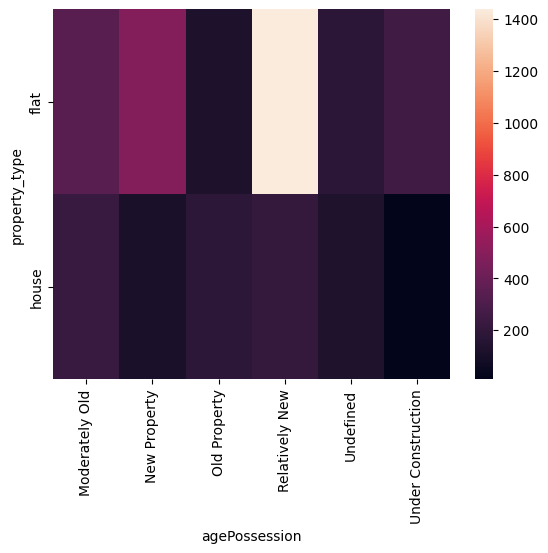

In [191]:
sns.heatmap(pd.crosstab(df['property_type'],df['agePossession']))

#### Observations

- Flats are predominantly **new or relatively new properties**, indicating higher availability in recently developed projects.
- Houses are more evenly distributed across **old, moderately old, and new categories**.
- For both property types, **new and relatively new properties command higher average prices**.
- Houses are consistently **priced higher than flats across all age categories**.
- Under-construction and undefined-age properties show **lower average prices**, likely due to uncertainty or incomplete data.


### property_type vs agePossession vs price

<Axes: xlabel='agePossession', ylabel='property_type'>

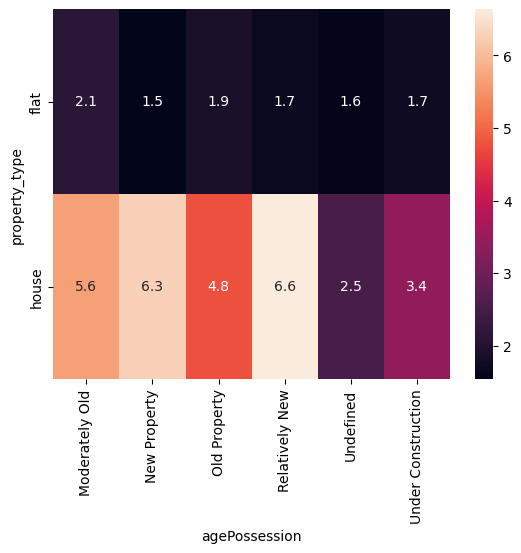

In [192]:
sns.heatmap(pd.pivot_table(df,index='property_type',columns='agePossession',values='price',aggfunc='mean'),annot=True)

#### Observations

- Flats are predominantly **new or relatively new properties**, indicating higher availability in recently developed projects.
- Houses are more evenly distributed across **old, moderately old, and new categories**.
- For both property types, **new and relatively new properties command higher average prices**.
- Houses are consistently **priced higher than flats across all age categories**.
- Under-construction and undefined-age properties show **lower average prices**, likely due to uncertainty or incomplete data.


### property_type vs bedRoom vs price

<Axes: xlabel='bedRoom', ylabel='property_type'>

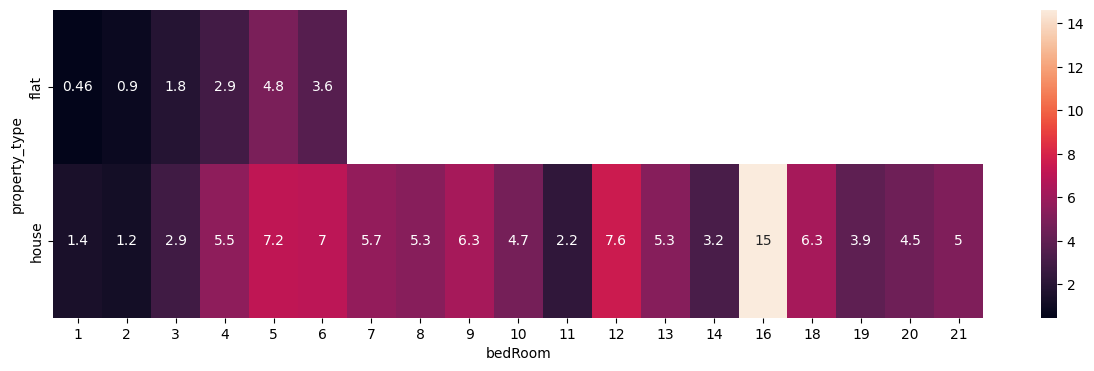

In [193]:
plt.figure(figsize=(15,4))
sns.heatmap(pd.pivot_table(df,index='property_type',columns='bedRoom',values='price',aggfunc='mean'),annot=True)

#### Observations

- For both flats and houses, **average price increases with the number of bedrooms**.
- Flats are mainly concentrated in **1–4 BHK**, with limited presence beyond this range.
- Houses span a **much wider bedroom range**, including high-BHK configurations.
- Extremely high bedroom counts show **price irregularities**, indicating **outliers or atypical properties**.


### property_type vs furnishing_type

<Axes: xlabel='furnishing_type', ylabel='property_type'>

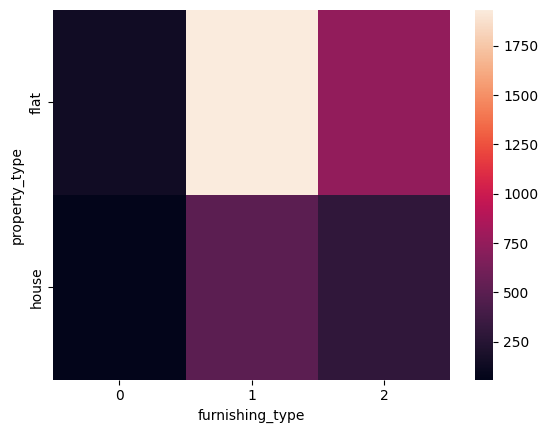

In [194]:
sns.heatmap(pd.crosstab(df['property_type'],df['furnishing_type']))

<Axes: xlabel='furnishing_type', ylabel='property_type'>

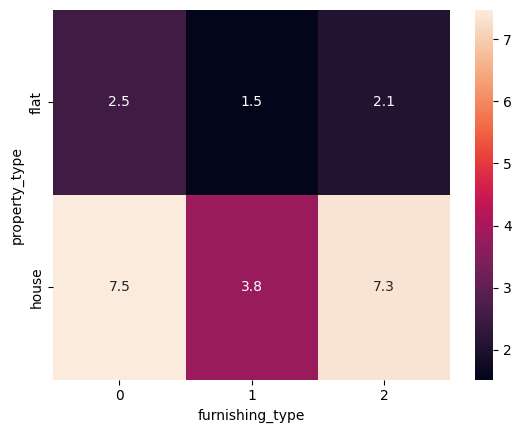

In [195]:
sns.heatmap(pd.pivot_table(df,index='property_type',columns='furnishing_type',values='price',aggfunc='mean'),annot=True)

#### Observations

- Flats are more commonly available in **unfurnished and semi-furnished** categories.
- Houses have fewer listings overall but show a **higher proportion of furnished units**.
- For both property types, **average price increases with the level of furnishing**.
- Houses are **consistently priced higher than flats** across all furnishing types.
- Fully furnished houses command the **highest average prices**, indicating a strong furnishing premium.


### property_type vs luxury_score

<Axes: xlabel='property_type', ylabel='luxury_score'>

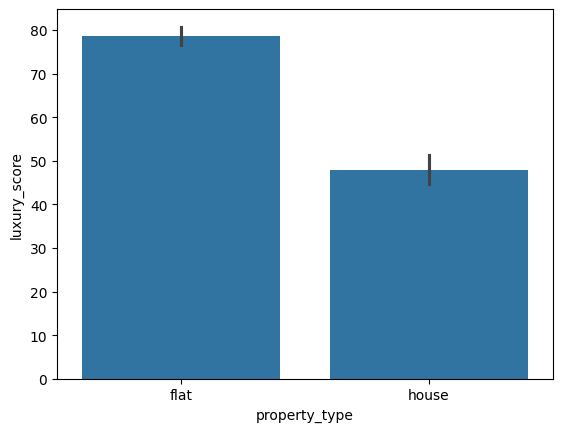

In [196]:
sns.barplot(x=df['property_type'],y=df['luxury_score'])

<Axes: xlabel='property_type', ylabel='luxury_score'>

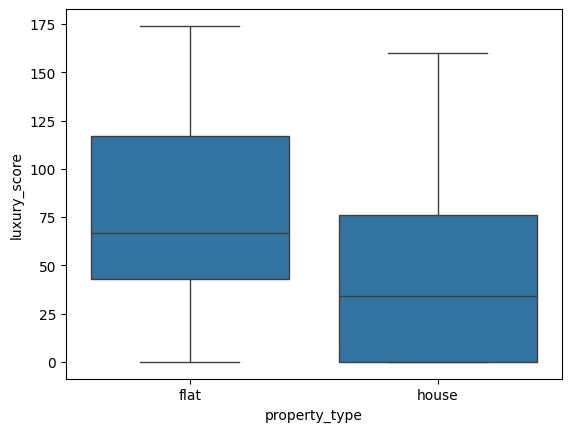

In [197]:
sns.boxplot(x=df['property_type'],y=df['luxury_score'])

### Observations

- Flats have a **higher average and median luxury score** compared to houses.
- Flats show **greater upper-end luxury values**, reflecting premium apartment amenities.
- Houses display **lower median luxury scores** with wider dispersion at the lower end.
- This suggests that **luxury in flats is driven by shared amenities**, while houses vary more by individual features.


### property_type vs sector

<Axes: xlabel='sector', ylabel='property_type'>

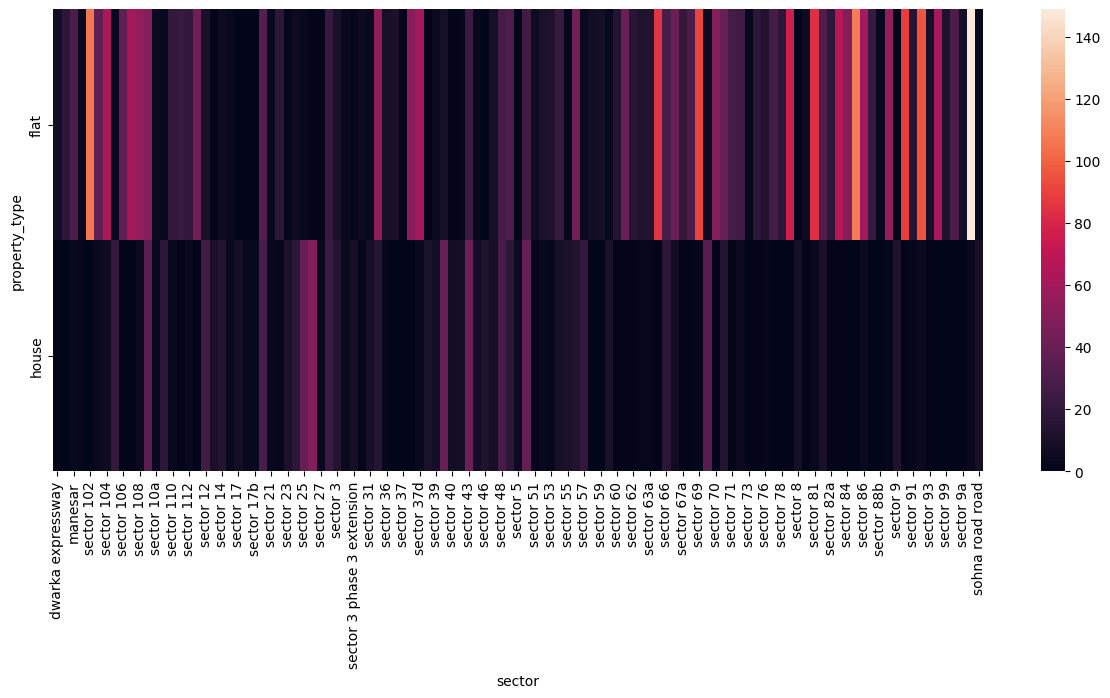

In [198]:
# sector analysis
plt.figure(figsize=(15,6))
sns.heatmap(pd.crosstab(df['property_type'],df['sector'].sort_index()))

#### Observations

- **Older sectors of Gurgaon are dominated by houses**, reflecting independent and low-rise developments.
- **Newer sectors show a higher concentration of flats**, indicating planned high-rise residential projects.


### Average Price per Sector

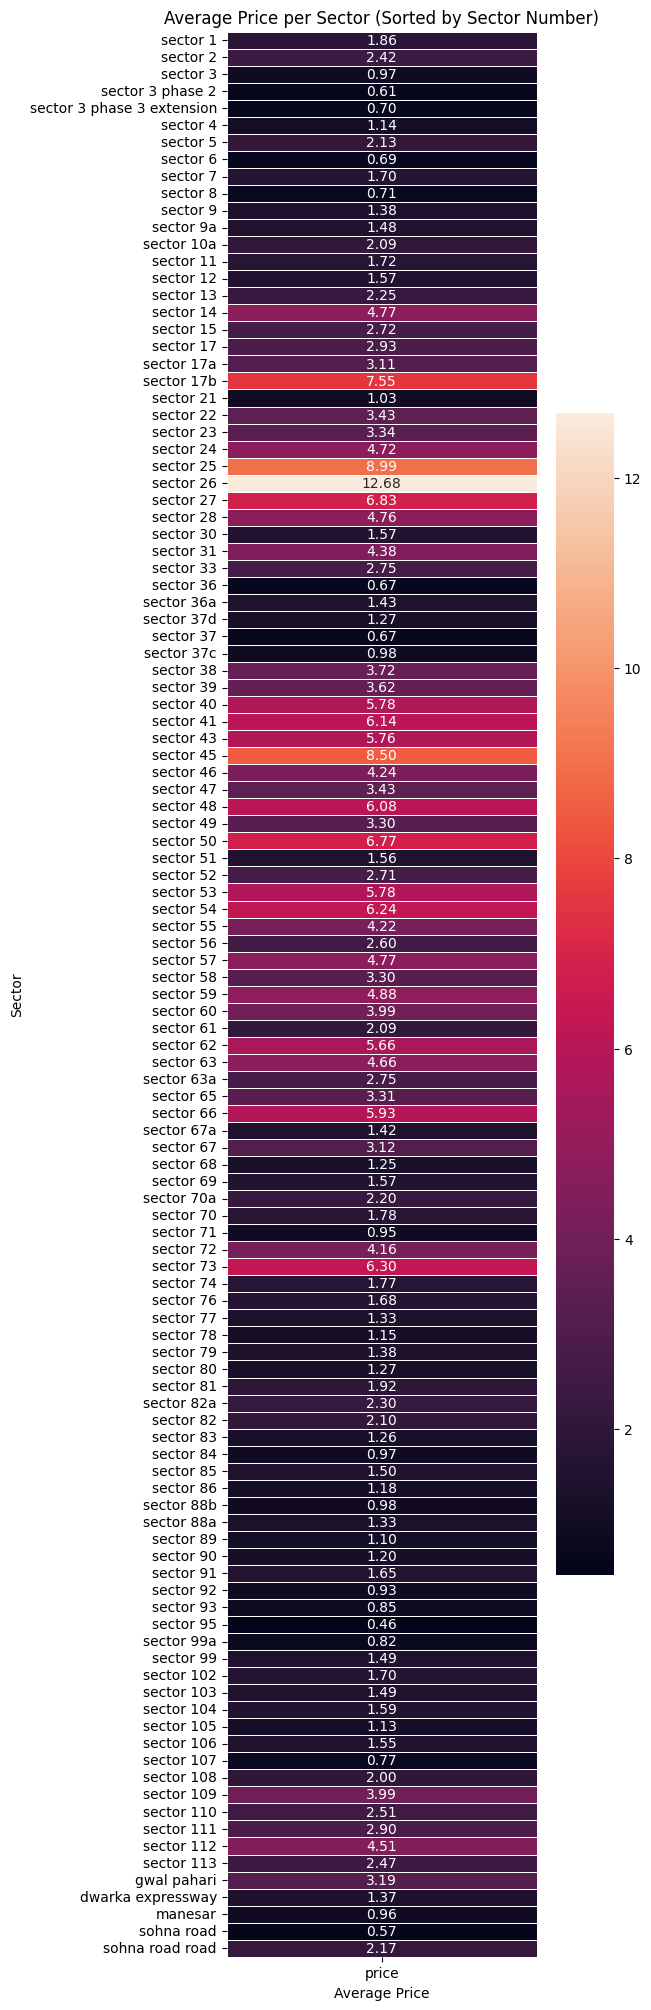

In [199]:
# sector analysis
import re
# Group by 'sector' and calculate the average price
avg_price_per_sector = df.groupby('sector')['price'].mean().reset_index()

# Function to extract sector numbers
def extract_sector_number(sector_name):
    match = re.search(r'\d+', sector_name)
    if match:
        return int(match.group())
    else:
        return float('inf')  # Return a large number for non-numbered sectors

avg_price_per_sector['sector_number'] = avg_price_per_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sector_sorted_by_sector = avg_price_per_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sector_sorted_by_sector.set_index('sector')[['price']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Price per Sector (Sorted by Sector Number)')
plt.xlabel('Average Price')
plt.ylabel('Sector')
plt.show()


#### Observations

- Property prices are **highest in centrally located sectors**.
- Early-developed sectors exhibit **lower average prices**, reflecting older housing stock and limited modern amenities.
- Recently developed peripheral sectors also show **comparatively lower prices**, likely due to ongoing development and distance from the core.


### Average Price per Sqft by Sector

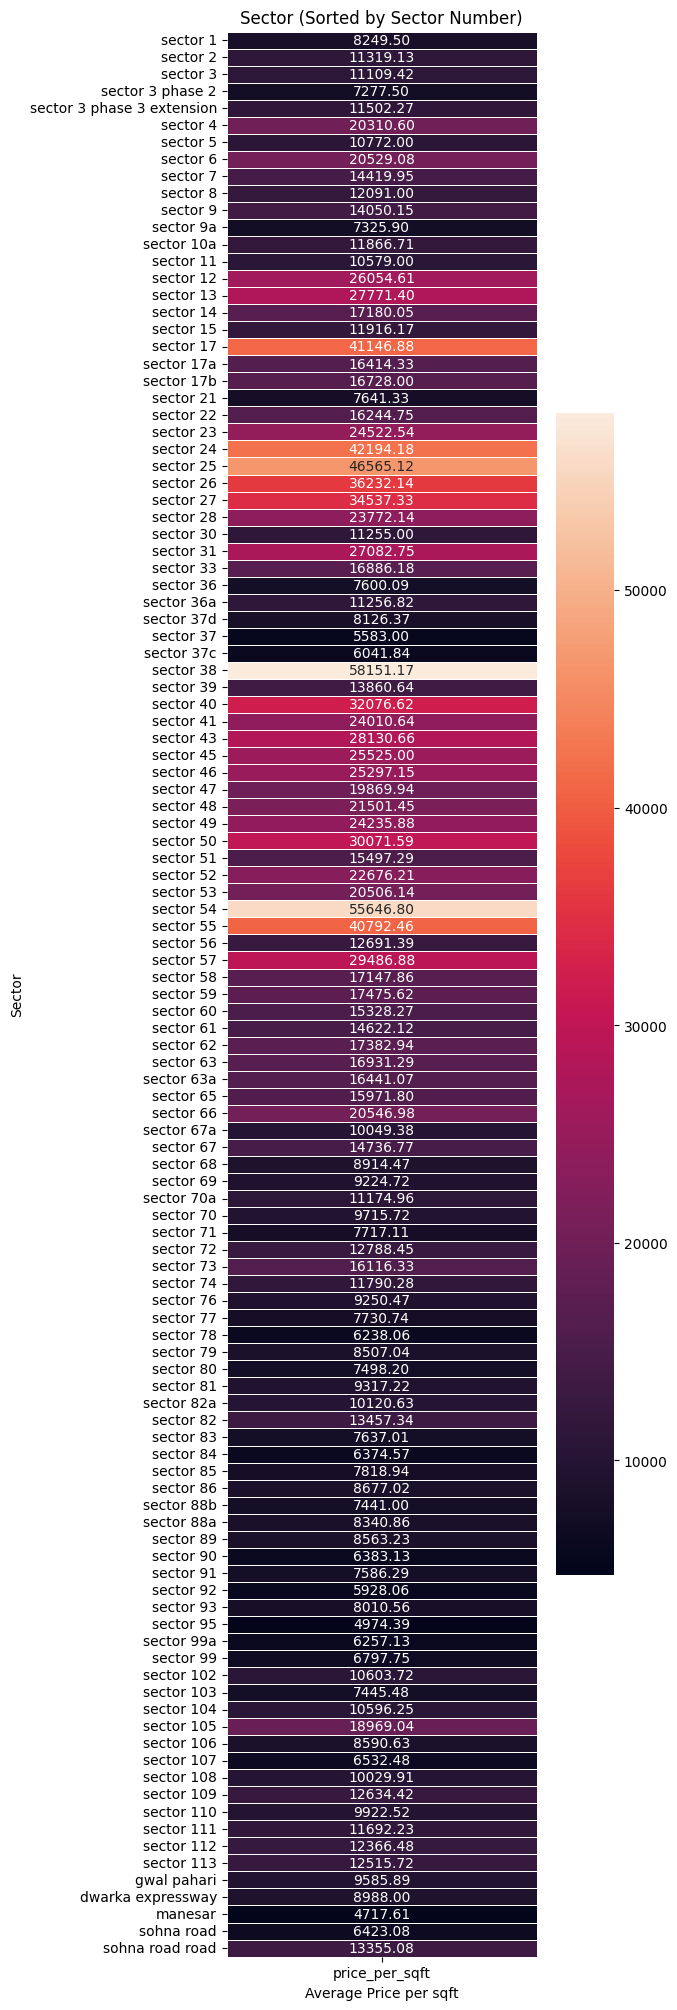

In [200]:
avg_price_per_sqft_sector = df.groupby('sector')['price_per_sqft'].mean().reset_index()

avg_price_per_sqft_sector['sector_number'] = avg_price_per_sqft_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sqft_sector_sorted_by_sector = avg_price_per_sqft_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sqft_sector_sorted_by_sector.set_index('sector')[['price_per_sqft']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Sector (Sorted by Sector Number)')
plt.xlabel('Average Price per sqft')
plt.ylabel('Sector')
plt.show()

#### Observations

- Price per sqft is **highest in centrally located sectors**, reflecting premium land value and demand.
- Early-developed sectors show **lower price-per-sqft levels**, driven by older constructions.
- Peripheral and newly added sectors also exhibit **comparatively lower price per sqft**, due to ongoing development.
- Overall, price per sqft follows a **core–periphery pattern**, similar to total property prices, but with sharper local variations.


### Average Luxury Score by Sector

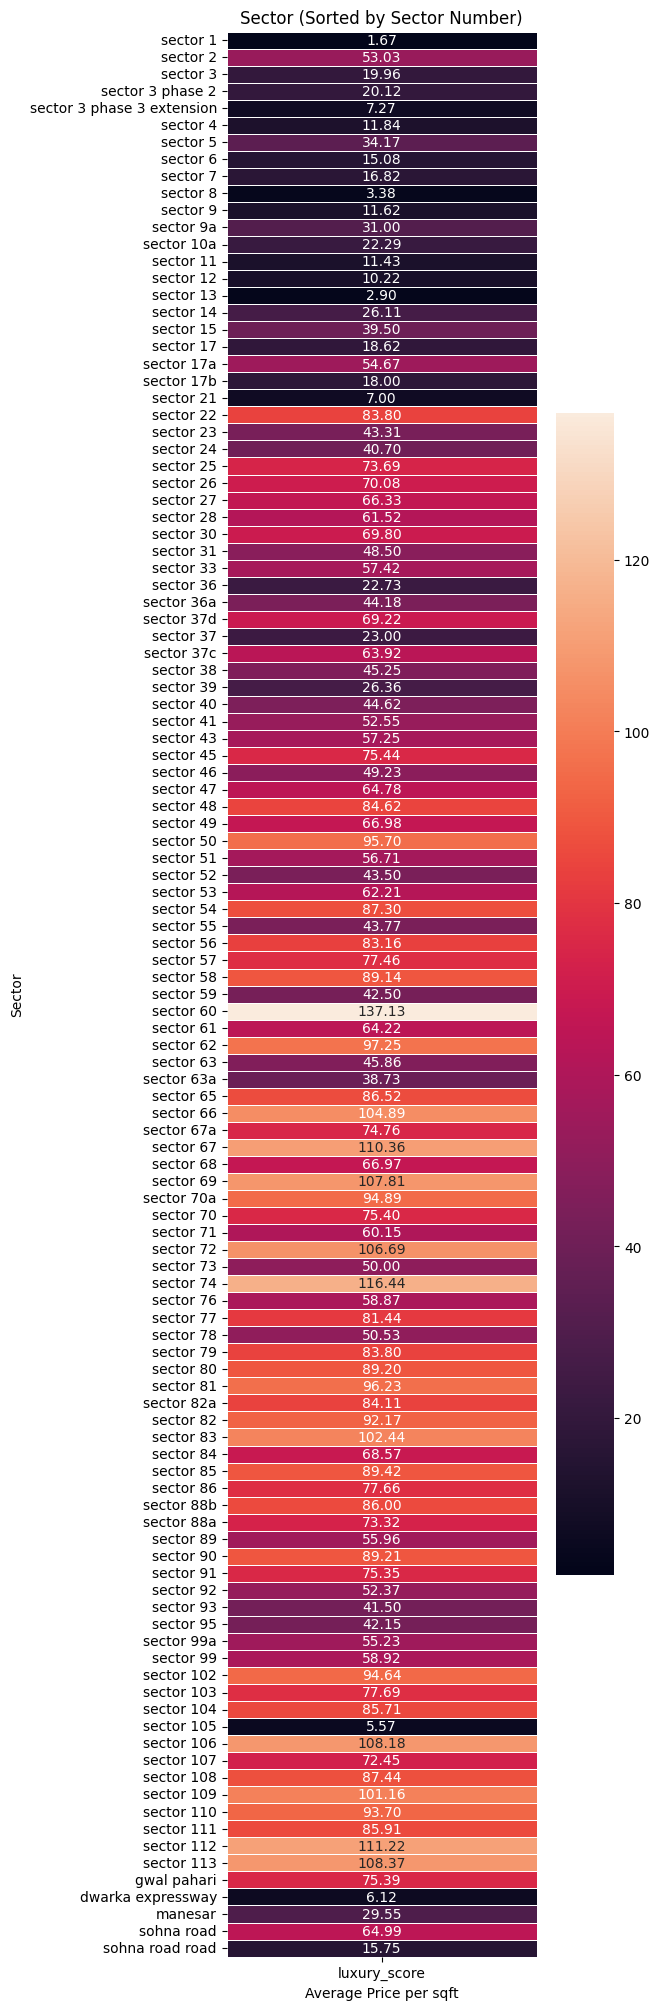

In [201]:
luxury_score = df.groupby('sector')['luxury_score'].mean().reset_index()

luxury_score['sector_number'] = luxury_score['sector'].apply(extract_sector_number)

# Sort by sector number
luxury_score_sector = luxury_score.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(luxury_score_sector.set_index('sector')[['luxury_score']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Sector (Sorted by Sector Number)')
plt.xlabel('Average Price per sqft')
plt.ylabel('Sector')
plt.show()

#### Observations

- Luxury scores are **highest in centrally located sectors**, reflecting premium amenities and planned developments.
- Early-developed sectors exhibit **lower average luxury scores**, indicating older housing stock with fewer modern facilities.
- Peripheral and newer sectors show **mixed but generally lower luxury scores**, suggesting ongoing development and gradual amenity buildup.


### price vs area

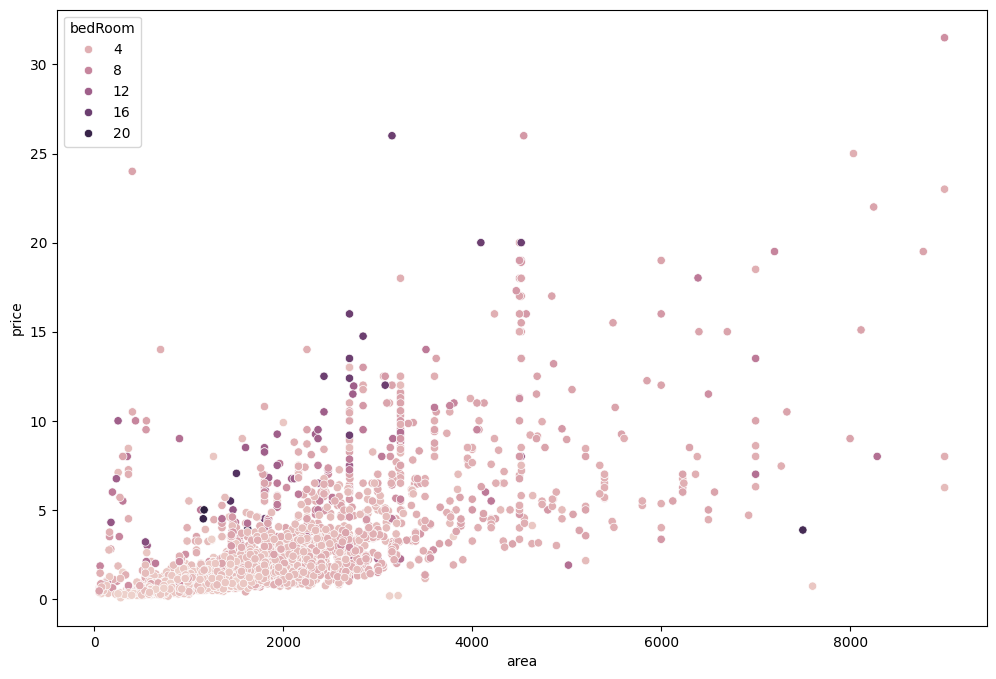

In [202]:
plt.figure(figsize=(12,8))
filtered_df = df[df['area'] < 10000]
sns.scatterplot(
    data=filtered_df,
    x='area',
    y='price',
    hue='bedRoom'
)
plt.show()

#### Observations

- Property price shows a **positive relationship with area**, with larger homes generally priced higher.
- Significant **price dispersion exists for similar area ranges**, indicating the influence of other factors beyond size.
- Properties with **higher bedroom counts tend to cluster at larger areas and higher prices**.
- Smaller-area properties mostly fall in the **lower price range**, regardless of bedroom count.
- Overall, **area and bedroom count jointly influence price**, but neither alone fully explains price variation.


### Area vs Price (By Age of Possession)

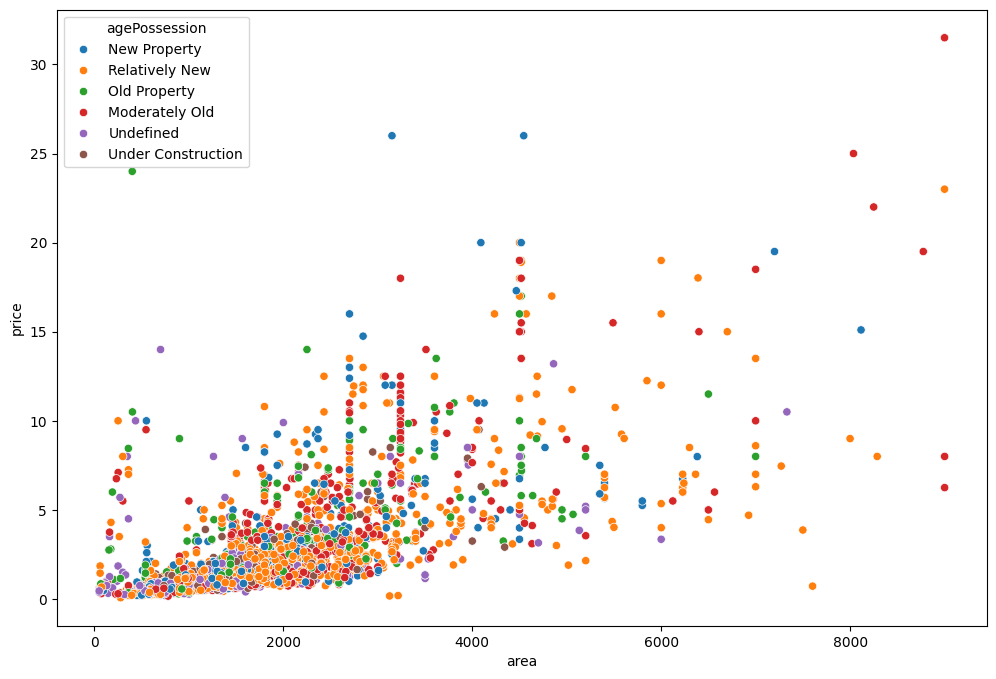

In [203]:
plt.figure(figsize=(12,8))
filtered_df = df[df['area'] < 10000]
sns.scatterplot(
    data=filtered_df,
    x='area',
    y='price',
    hue='agePossession'
)
plt.show()

#### Observations

- Price generally **increases with area** across all age categories.
- **New and relatively new properties** tend to command higher prices for similar areas.
- Older properties cluster at **lower price levels**.


### Area vs Price (By Furnishing Type)

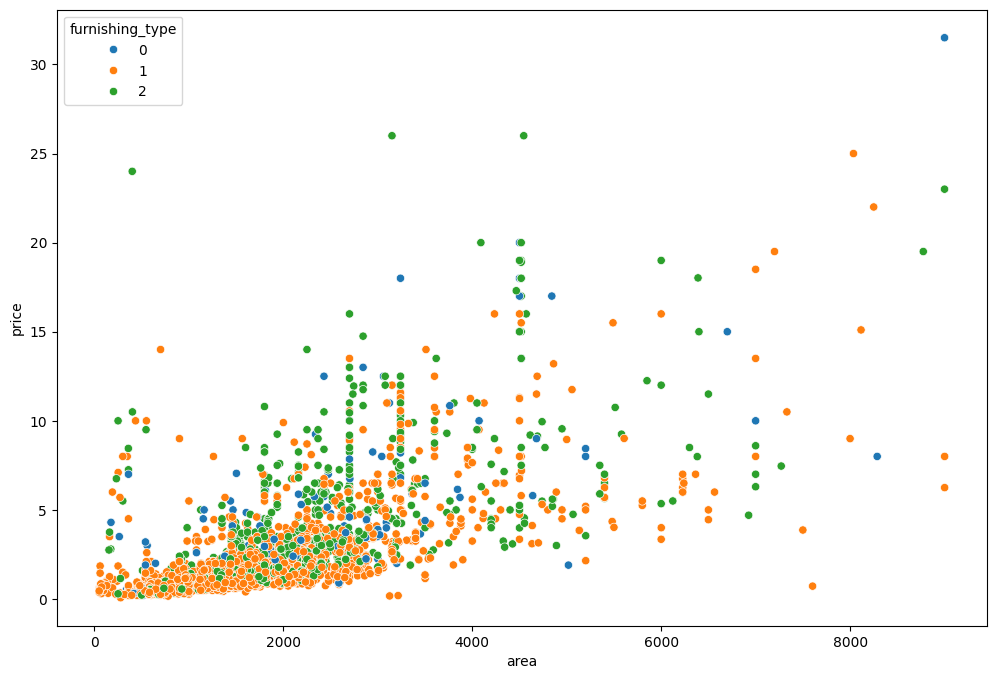

In [204]:
plt.figure(figsize=(12,8))
filtered_df = df[df['area'] < 10000]
sns.scatterplot(
    data=filtered_df,
    x='area',
    y='price',
    hue=filtered_df['furnishing_type'].astype('category')
)
plt.show()

#### Observations

- Price generally **increases with area** across all furnishing types.
- **Furnished properties** tend to appear at **higher price levels** for similar areas.
- Unfurnished units cluster more in the **lower price range**.


### Bedrooms vs Price

<Axes: xlabel='bedRoom', ylabel='price'>

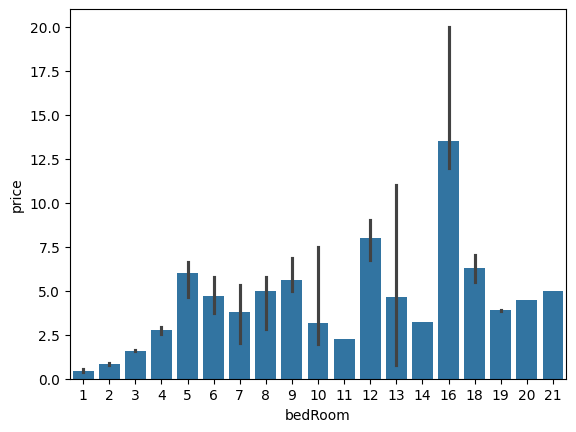

In [205]:
sns.barplot(x=df['bedRoom'],y=df['price'],estimator=np.median)

#### Observations

- Median price **generally increases with bedroom count**.
- Lower BHK units (1–3) are concentrated in the **lower price range**.
- Higher BHK units command **higher prices but show greater variability**.
- Extreme bedroom counts show **price irregularities**, indicating limited data or outliers.


### Age of Possession vs Price

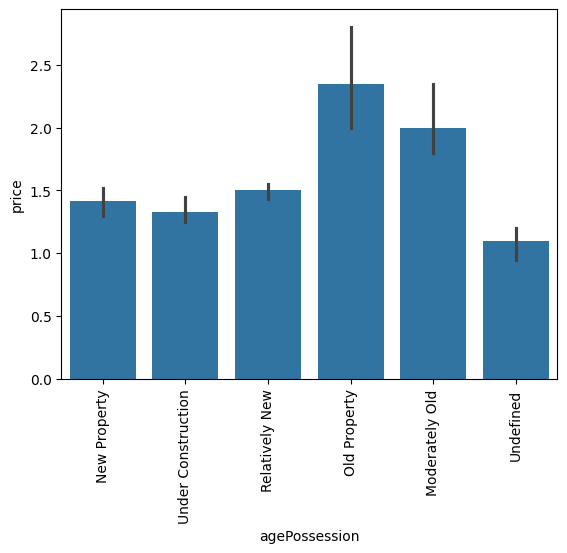

In [206]:
sns.barplot(x=df['agePossession'],y=df['price'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

#### Observations

- Older properties show a **higher median price** compared to newer ones.
- Moderately old properties also command **relatively high prices**.
- New and under-construction properties are priced **lower on average**.


### Age of Possession vs Area

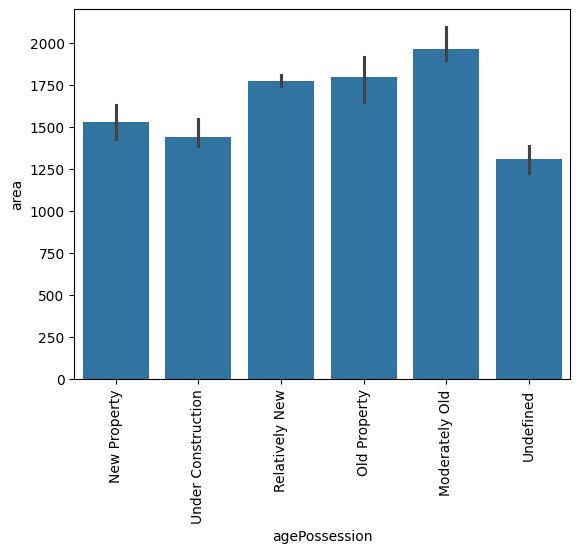

In [207]:
sns.barplot(x=df['agePossession'],y=df['area'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

#### Observations

- Older and moderately old properties have **larger median built-up areas**.
- New and under-construction properties tend to have **smaller areas**.
- Relatively new properties fall **between old and new constructions**.
- Undefined-age listings show the **lowest median area**, likely due to data uncertainty.


### Furnishing Type vs Price

<Axes: xlabel='furnishing_type', ylabel='price'>

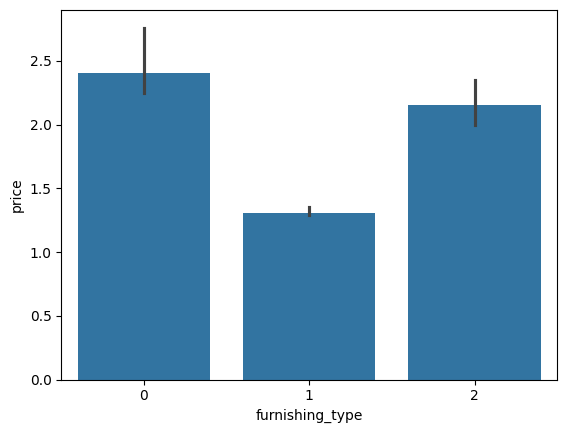

In [208]:
sns.barplot(x=df['furnishing_type'],y=df['price'],estimator=np.median)

##### Observations

- Median price **increases with furnishing level**.
- Unfurnished properties are **priced lowest**.
- Semi-furnished and furnished units command a **clear price premium**.


### Luxury Score vs Price

<Axes: xlabel='luxury_score', ylabel='price'>

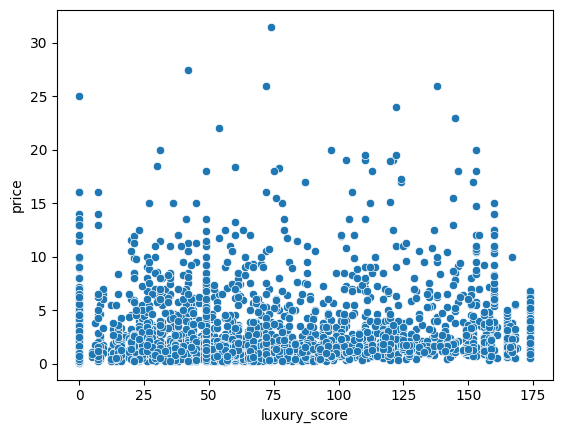

In [209]:
sns.scatterplot(
    data=df,
    x='luxury_score',
    y='price'
)

#### Observations

- Property **price generally increases with luxury score**, though the relationship is weak.
- High luxury scores do **not always translate to high prices**, indicating other influencing factors.
- Considerable **price dispersion exists across all luxury levels**.


### Correlation Analysis

Analyze correlations between numerical variables to identify relationships.

<Axes: >

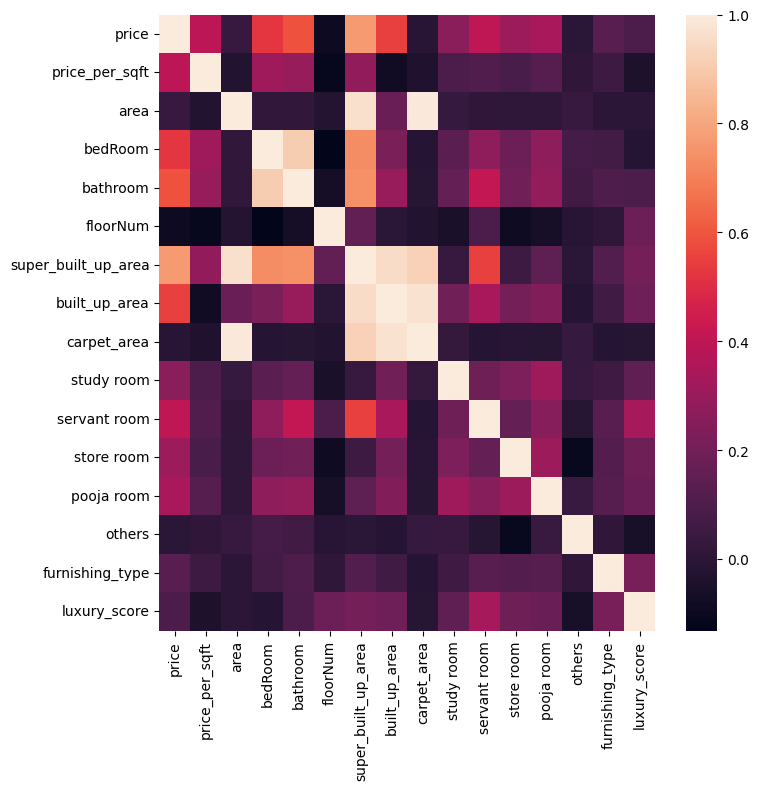

In [210]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True))

#### Observations

- Property **price is strongly correlated with area-related features** (built-up, super built-up, carpet area).
- **Bedroom and bathroom counts show moderate positive correlation** with price.
- **Price per sqft has a weak correlation with total price**, indicating different pricing dynamics.
- Area variables are **highly correlated among themselves**, suggesting multicollinearity.
- Luxury score and furnishing type show **only weak correlations with price**.


In [212]:
df.select_dtypes(include='number').corr()['price'].sort_values(ascending=False)

price                  1.000000
super_built_up_area    0.769412
bathroom               0.589826
built_up_area          0.551649
bedRoom                0.522925
servant room           0.400927
price_per_sqft         0.391251
pooja room             0.341492
store room             0.309121
study room             0.258602
furnishing_type        0.133418
luxury_score           0.094775
area                   0.034720
others                -0.003525
carpet_area           -0.011344
floorNum              -0.094290
Name: price, dtype: float64